# Benchmark de SAN en GPU

Evalúa el checkpoint disponible de **SAN** sobre CROHME con el mismo protocolo usado para TSDNet: tres calentamientos, entrada residente en GPU, sincronización CUDA, latencia por muestra, tiempo total de inferencia, exact match y pico incremental de VRAM. Los resultados se guardan en `01_seleccion/resultados`.

In [1]:
from pathlib import Path
import gc, json, os, platform, sys, time
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..', Path.cwd() / '../..']:
        candidate = candidate.resolve()
        if (candidate / 'SAN').is_dir() and (candidate / 'data').is_dir(): return candidate
    raise FileNotFoundError('No se encontró la raíz con SAN/ y data/.')
ROOT = find_project_root()
SAN_ROOT = ROOT / 'SAN'
RESULTS_DIR = ROOT / 'Cascada' / '01_seleccion' / 'resultados'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE, MB = torch.device('cuda:0'), 1024 ** 2
assert torch.cuda.is_available(), 'CUDA no está disponible.'
print('Raíz:', ROOT); print('GPU:', torch.cuda.get_device_name(0)); print('PyTorch:', torch.__version__)

Raíz: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch: 2.0.1+cu118


## Carga del modelo y del checkpoint

In [2]:
sys.path.insert(0, str(SAN_ROOT))
from utils import load_config
from infer.Backbone import Backbone
from dataset import Words
params = load_config(SAN_ROOT / '14.yaml')
params['device'] = DEVICE
params['word_path'] = str(SAN_ROOT / 'data' / 'word.txt')
params['checkpoint'] = str(SAN_ROOT / 'checkpoints' / 'SAN_decoder' / 'best.pth')
words = Words(params['word_path'])
params['word_num'], params['struct_num'], params['words'] = len(words), 7, words
model = Backbone(params)
state = torch.load(params['checkpoint'], map_location='cpu', weights_only=True)
model.load_state_dict(state['model'])
model = model.to(DEVICE).eval().requires_grad_(False)
torch.cuda.synchronize()
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
model_allocated_mib = torch.cuda.memory_allocated() / MB
print(f'Parámetros: {parameter_count:,} ({parameter_count / 1e6:.3f} M)')
print(f'Pesos + buffers: {(parameter_bytes + buffer_bytes) / MB:.2f} MiB')
print(f'VRAM asignada tras cargar: {model_allocated_mib:.2f} MiB')

try UTF-8 encoding
115 symbols in total


C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Parámetros: 7,996,103 (7.996 M)
Pesos + buffers: 30.55 MiB
VRAM asignada tras cargar: 30.70 MiB


In [3]:
def prediction_to_latex(prediction):
    if prediction is None or len(prediction) <= 1: return '<sin predicción>'
    children = {}
    for item in prediction:
        if len(item) < 4: continue
        try: node_id, parent_id = int(item[1]), int(item[2])
        except (TypeError, ValueError): continue
        children.setdefault(parent_id, []).append((node_id, str(item[3])))
    def walk(node_id):
        if node_id < 0 or node_id >= len(prediction): return ['<invalid>']
        symbol, kids = str(prediction[node_id][0]), children.get(node_id, [])
        if not kids: return [symbol]
        result = [symbol]
        if symbol == r'\frac':
            for relation_name in ('Above', 'Below'):
                for child_id, relation in kids:
                    if relation == relation_name: result += ['{'] + walk(child_id) + ['}']
            for child_id, relation in kids:
                if relation == 'Right': result += walk(child_id)
            return result
        for child_id, relation in kids:
            if relation == 'l_sup': result += ['['] + walk(child_id) + [']']
        for child_id, relation in kids:
            if relation == 'Inside': result += ['{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sub', 'Below'): result += ['_', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sup', 'Above'): result += ['^', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation == 'Right': result += walk(child_id)
        return result
    try: return ' '.join(walk(1))
    except Exception as exc: return f'<error SAN: {exc}>'

def prepare_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None: raise FileNotFoundError(path)
    tensor = torch.from_numpy(image).float().div_(255).unsqueeze(0).unsqueeze(0)
    mask = torch.ones_like(tensor)
    return tensor.to(DEVICE), mask.to(DEVICE), image.shape

## Configuración

`MAX_SAMPLES = None` procesa toda la partición. Para una prueba rápida se puede usar un entero.

In [4]:
YEAR = '2014'
MAX_SAMPLES = None
WARMUP_RUNS = 3
PROGRESS_EVERY = 25
split_dir = ROOT / 'data' / 'Modelo1' / YEAR
image_dir = split_dir / '14_test_images'
samples = []
for line in (split_dir / 'test_caption.txt').read_text(encoding='utf-8').splitlines():
    parts = line.strip().split()
    if parts:
        sample_id = parts[0][:-4] if parts[0].endswith('.jpg') else parts[0]
        samples.append((sample_id, ' '.join(parts[1:])))
if MAX_SAMPLES is not None: samples = samples[:MAX_SAMPLES]
print(f'Muestras seleccionadas: {len(samples)} | CROHME {YEAR}')
warm_image, warm_mask, _ = prepare_image(image_dir / f'{samples[0][0]}_0.bmp')
with torch.inference_mode():
    for _ in range(WARMUP_RUNS):
        output = model(warm_image, warm_mask); torch.cuda.synchronize(); del output
del warm_image, warm_mask; gc.collect(); torch.cuda.synchronize()
print(f'Warm-up terminado: {WARMUP_RUNS} ejecuciones.')

Muestras seleccionadas: 986 | CROHME 2014


Warm-up terminado: 3 ejecuciones.


In [5]:
rows = []
for index, (sample_id, ground_truth) in enumerate(samples, start=1):
    path = image_dir / f'{sample_id}_0.bmp'
    row = {'index': index, 'sample_id': sample_id, 'image_file': path.name, 'ground_truth': ground_truth, 'status': 'ok', 'error': ''}
    try:
        image, mask, (height, width) = prepare_image(path)
        gc.collect(); torch.cuda.synchronize(); baseline = torch.cuda.memory_allocated(); torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize(); start = time.perf_counter()
        with torch.inference_mode(): raw_prediction = model(image, mask)
        torch.cuda.synchronize(); elapsed_ms = (time.perf_counter() - start) * 1000
        peak = torch.cuda.max_memory_allocated(); prediction = prediction_to_latex(raw_prediction)
        row.update({'height': height, 'width': width, 'prediction': prediction, 'correct': int(prediction.strip() == ground_truth.strip()), 'time_ms': elapsed_ms, 'base_mib': baseline / MB, 'peak_total_mib': peak / MB, 'peak_increment_mib': (peak - baseline) / MB})
        del raw_prediction, image, mask
    except Exception as exc:
        row.update({'status': 'error', 'error': f'{type(exc).__name__}: {exc}', 'correct': np.nan, 'time_ms': np.nan, 'peak_increment_mib': np.nan})
    rows.append(row); gc.collect()
    if index % PROGRESS_EVERY == 0 or index == len(samples):
        valid_now = [r for r in rows if r['status'] == 'ok']
        print(f'{index:4d}/{len(samples)} | válidas={len(valid_now):4d} | latencia media={np.mean([r["time_ms"] for r in valid_now]):.2f} ms')

  25/986 | válidas=  25 | latencia media=151.86 ms


  50/986 | válidas=  50 | latencia media=143.55 ms


  75/986 | válidas=  75 | latencia media=140.44 ms


 100/986 | válidas= 100 | latencia media=140.30 ms


 125/986 | válidas= 125 | latencia media=137.44 ms


...

 900/986 | válidas= 900 | latencia media=121.24 ms


 925/986 | válidas= 925 | latencia media=121.04 ms


 950/986 | válidas= 950 | latencia media=120.85 ms


 975/986 | válidas= 975 | latencia media=120.60 ms


 986/986 | válidas= 986 | latencia media=120.05 ms


In [6]:
results = pd.DataFrame(rows); valid = results[results['status'] == 'ok'].copy(); latencies = valid['time_ms'].to_numpy()
_, total_bytes = torch.cuda.mem_get_info()
summary = {
    'model': 'SAN', 'dataset': f'CROHME {YEAR}', 'samples_requested': len(samples), 'samples_valid': len(valid), 'errors': int((results['status'] != 'ok').sum()),
    'exact_match_percent': float(valid['correct'].mean() * 100), 'latency_mean_ms': float(np.mean(latencies)), 'latency_median_ms': float(np.median(latencies)), 'latency_p95_ms': float(np.percentile(latencies, 95)),
    'latency_min_ms': float(np.min(latencies)), 'latency_max_ms': float(np.max(latencies)), 'total_inference_seconds': float(np.sum(latencies) / 1000), 'total_inference_minutes': float(np.sum(latencies) / 60000),
    'parameters': parameter_count, 'parameters_millions': parameter_count / 1e6, 'weights_buffers_mib': (parameter_bytes + buffer_bytes) / MB, 'model_allocated_mib': model_allocated_mib,
    'max_peak_total_mib': float(valid['peak_total_mib'].max()), 'max_peak_increment_mib': float(valid['peak_increment_mib'].max()), 'gpu': torch.cuda.get_device_name(0), 'gpu_total_mib': total_bytes / MB,
    'python': platform.python_version(), 'pytorch': torch.__version__, 'cuda': torch.version.cuda, 'warmup_runs': WARMUP_RUNS, 'timing_scope': 'Inferencia GPU; excluye lectura y preprocesamiento CPU.'}
csv_path = RESULTS_DIR / f'benchmark_san_crohme_{YEAR}.csv'; json_path = RESULTS_DIR / f'resumen_san_crohme_{YEAR}.json'
results.to_csv(csv_path, index=False, encoding='utf-8'); json_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([summary]).T.rename(columns={0: 'valor'})); print('CSV:', csv_path); print('Resumen:', json_path)

,valor
model,SAN
dataset,CROHME 2014
samples_requested,986
samples_valid,986
errors,0
exact_match_percent,56.592292
latency_mean_ms,120.045563
latency_median_ms,115.98985
latency_p95_ms,233.010625
latency_min_ms,16.6503


CSV: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_san_crohme_2014.csv
Resumen: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\resumen_san_crohme_2014.json


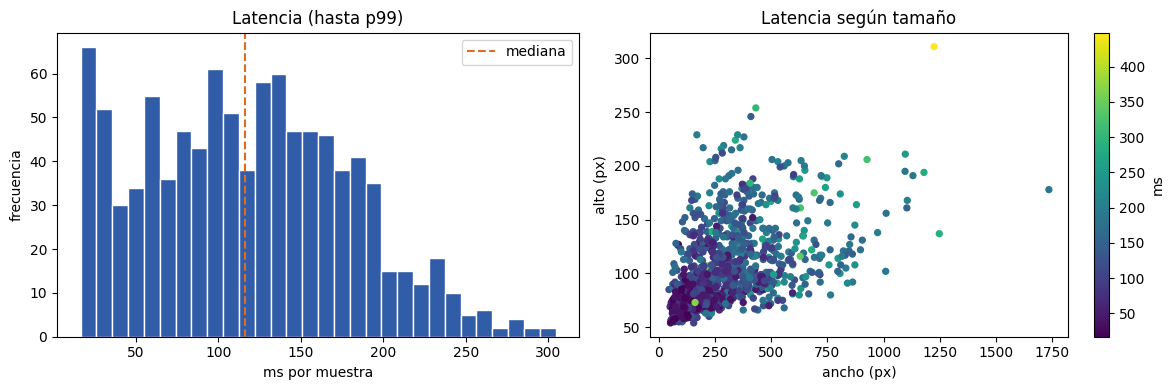

Gráfica: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_san_crohme_2014.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); display_limit = np.percentile(valid['time_ms'], 99)
axes[0].hist(valid.loc[valid['time_ms'] <= display_limit, 'time_ms'], bins=30, color='#315da8', edgecolor='white'); axes[0].axvline(summary['latency_median_ms'], color='#dd6b20', linestyle='--', label='mediana')
axes[0].set(title='Latencia (hasta p99)', xlabel='ms por muestra', ylabel='frecuencia'); axes[0].legend()
scatter = axes[1].scatter(valid['width'], valid['height'], c=valid['time_ms'], cmap='viridis', s=18); axes[1].set(title='Latencia según tamaño', xlabel='ancho (px)', ylabel='alto (px)'); fig.colorbar(scatter, ax=axes[1], label='ms')
fig.tight_layout(); plot_path = RESULTS_DIR / f'benchmark_san_crohme_{YEAR}.png'; fig.savefig(plot_path, dpi=160, bbox_inches='tight'); plt.show(); print('Gráfica:', plot_path)

## Lectura de los resultados

- Exact match compara la secuencia LaTeX predicha con el ground truth.
- Latencia y tiempo total contabilizan solo inferencia GPU.
- Pico incremental resta la memoria asignada inmediatamente antes de cada inferencia.